In [197]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [198]:
class Value:

    def __init__(self, data, _children=(),_op='',label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None

        
    def __repr__(self):
        return f"Value(data={self.data})"


    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out  = Value(self.data + other.data, (self,other),'+')

        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward

        return out

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad +=  other * self.data**(other-1) * out.grad
        out._backward = _backward     

        return out

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self + (-other)

        
    def __rmul__(self,other):
        return self*other    

    def __radd__(self,other):
        return self+other        

    def __truediv__(self,other):
        return self*other**-1


    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        
        def _backward():
            self.grad += (1-t**2)*out.grad
        
        out._backward = _backward
        
        return out

    
    def exp(self):
        x =self.data
        out = Value(math.exp(x),(self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward  = _backward

        return out    



    def backward(self):
        

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0                    

        for v in reversed(topo):
            v._backward()        

       
    

In [199]:
a = Value(2)
a.exp() 

Value(data=7.38905609893065)

In [200]:
a = Value(2.0)
a+1
a*2
2*a  

Value(data=4.0)

In [201]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data%.4f |grad%.4f }" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            dot.node(name = uid +n._op, label = n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [202]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()


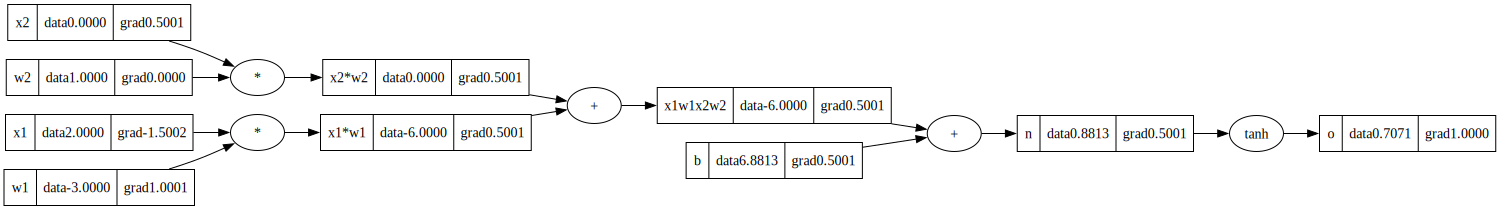

In [203]:
draw_dot(o)

In [204]:
o.backward()

In [205]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1w1.grad = 0.5
x2w2.grad = 0.5
x1w1x2w2.grad =0.5
b.grad = 0.5
n.grad = 0.5

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

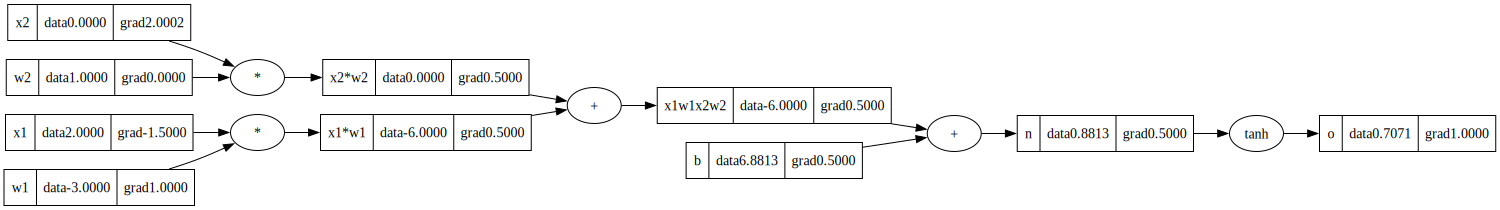

In [206]:
draw_dot(o)

In [207]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; 
n.label = 'n'

o = n.tanh(); o.label = 'o'
o.backward()


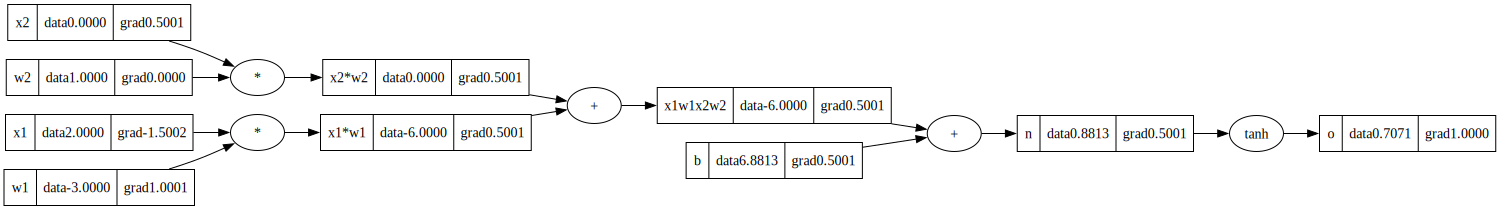

In [208]:
draw_dot(o)

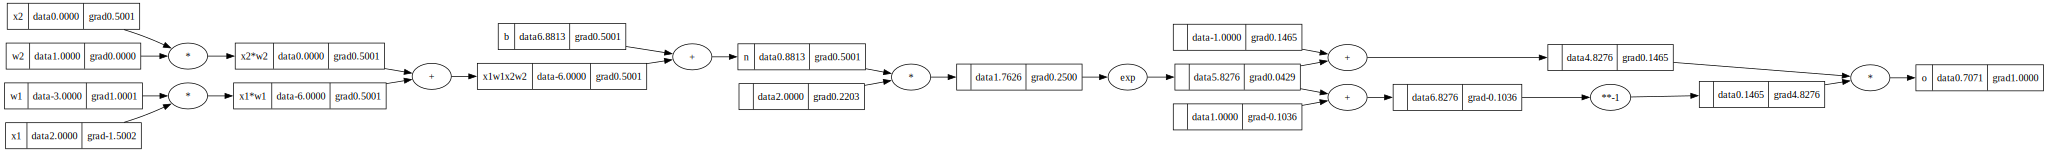

In [209]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; 
n.label = 'n'

e = (2*n).exp();
o = (e-1)/(e+1);
o.label = 'o'
o.backward()
draw_dot(o)


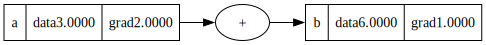

In [210]:
a = Value(3.0, label = 'a')
b = a+a;
b.label = 'b'
b.backward()
draw_dot(b)

In [211]:
a = Value(2.0)
b = Value(4.0)
a-b

Value(data=-2.0)

In [212]:
import torch

In [213]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True; # cast to double since python uses float64 and pytorch uses float32
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True; # since these are leaf nodes, pytorch assumes they dont require gradient, by default set to false due to efficiency reason
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True;
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True;

b = torch.Tensor([6.8813]).double(); b_requires_grad = True;
n=x1*w1 + x2*w2 + b;
o = torch.tanh(n);


print(o.data.item())
o.backward()


print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7070699720278941
---
x2 0.5000520546564731
w2 0.0
x1 -1.5001561639694192
w1 1.0001041093129461


In [214]:
o.item()
import random

using tensors in torch is much efficient due to parallel computing possible

In [215]:
class Neuron:

    def __init__(self, nin): # nin = number of inputs a neuron takes
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]# create a random weight for all inputs between -1 and 1
        self.b = Value(random.uniform(-1,1))


    def __call__(self,x):
        act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)     
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]        


class Layer:

    def __init__(self,nin,nout): # nout = number of outputs = number of neurons in layer
        self.neurons = [Neuron(nin) for _ in range(nout)]# nin = num of inputs each neuron takes

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]

        return outs[0] if len(outs) ==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
      
      
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters
        #     params.extend(ps)
        # return params    


class MLP:

    def __init__(self, nin, nouts):# nouts = output list for each layer
        sz = [nin]+nouts # size list for each layer
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))] # create a layer obj for each layer

    def __call__(self,x):
        for layer in self.layers:
            # sequentially calling each layer
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]    



x = [2.0,3.0,-1.0] # initial inputs
n = MLP(3,[4,4,1])

n(x)


Value(data=0.4870614438494568)

In [216]:
n.parameters()

[Value(data=-0.7265520814625879),
 Value(data=0.49530688831273095),
 Value(data=0.8563965597481646),
 Value(data=-0.5882142568302255),
 Value(data=0.6476547300784532),
 Value(data=0.23718229388522372),
 Value(data=-0.2702101644835906),
 Value(data=0.5034710072936082),
 Value(data=-0.6235973644659534),
 Value(data=0.1524239452551408),
 Value(data=0.713662005186259),
 Value(data=0.5844042269434737),
 Value(data=-0.6969509703690031),
 Value(data=0.753631909872646),
 Value(data=-0.11081091305882773),
 Value(data=-0.9848427776167956),
 Value(data=0.8364908285213404),
 Value(data=-0.3119543166289911),
 Value(data=0.7603918149988722),
 Value(data=-0.695611165187443),
 Value(data=-0.2907880735077226),
 Value(data=0.03278019087133832),
 Value(data=0.6454577957837111),
 Value(data=-0.6782854993212524),
 Value(data=0.9713002728784035),
 Value(data=0.6062793382637832),
 Value(data=-0.5539267318659828),
 Value(data=-0.09452417352857134),
 Value(data=0.17109642576213013),
 Value(data=0.1615090291447

In [217]:
xs = [

    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
    
]
ys = [1.0,-1.0,-1.0,1.0] # desired target for each row of xs





In [249]:
# we want minimize the loss in predicting values 
# values should be close to ys

for k in range(20):

#forward pass
    ypred = [n(x) for x in xs]
    loss =  sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0
# backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05*p.grad

    print(k, loss.data)    

0 0.0016846013489041287
1 0.0016786698672756062
2 0.0016727791034975505
3 0.0016669286431437987
4 0.001661118077368975
5 0.00165534700281519
6 0.001649615021520541
7 0.0016439217408293484
8 0.001638266773304303
9 0.0016326497366402832
10 0.0016270702535798928
11 0.0016215279518306076
12 0.0016160224639836145
13 0.001610553427434248
14 0.0016051204843038603
15 0.0015997232813632942
16 0.0015943614699578746
17 0.0015890347059337399
18 0.0015837426495656595
19 0.0015784849654862194


In [250]:
ypred

[Value(data=0.983846667018939),
 Value(data=-0.9779581198525248),
 Value(data=-0.9869512192353697),
 Value(data=0.9742815311651308)]